# IY033 – Condition-first Hierarchical Classification: Old Dataset 

**Goal:** Classify time series by **carbon-source condition** (condition-first, ignoring TF identity) comparing three classifiers:
1. **Raw SVM (RBF)** — truncated time series as a flat feature vector
2. **Catch22 + SVM** — 22 canonical time-series features (length-agnostic)
3. **SimCLR + SVM** — pre-trained transformer embeddings (IY017/022/023/024 checkpoints)

**Dataset:** Steady-state (`4_transformed_exp_time_series/`).
**Data sources:** Same 6 TF+condition groups as IY031 (Nrg1 and Rtg1 at 3 glucose concentrations) — labels collapsed to condition only → **3 classes**.
**Labels:** Carbon-source condition (not "TF @ condition"); TF identity is discarded.
**Excluded:** Experiment 18446 (not properly recorded).
**Note:** Raw SVM and Catch22 use un-normalised traces; SimCLR uses batch-wise z-score per timepoint.

In [1]:
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pycatch22
import torch
from pathlib import Path
from matplotlib.patches import Patch
from IPython.display import display
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
from models.ssl_transformer import SSL_Transformer

RANDOM_STATE = 42

# Same 6 TF+condition data sources as IY031 (Nrg1 & Rtg1 at 3 glucose conditions).
# All other (tf, condition) pairs are tagged __skip__ and discarded by prepare_dataset.
FIXED_SOURCE_TF_CONDS = {
    ("Nrg1", "0.01% glucose"),
    ("Nrg1", "0.1% glucose"),
    ("Nrg1", "2% glucose (mock/steady)"),
    ("Rtg1", "0.01% glucose"),
    ("Rtg1", "0.1% glucose"),
    ("Rtg1", "2% glucose (mock/steady)"),
}
# Labels are condition-only — Nrg1 and Rtg1 are pooled within each condition.
COND_CLASSES = sorted({cond for _, cond in FIXED_SOURCE_TF_CONDS})

IY033_DIR   = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY033")
IY008_DIR   = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008")
EXP_DIR     = Path("/home/ianyang/stochastic_simulations/experiments")
SS_DATA_DIR = IY008_DIR / "4_transformed_exp_time_series"
META_PATH   = IY008_DIR / "old_data_metadata.csv"
META_COLS   = ["id", "group", "experiment"]

EXCLUDED_EXPS = {"18446"}
FILE_RE       = re.compile(r"^(\d+)_.*_group_(.+?)_(GFP|mCherry)_time_series$")
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif", "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")
print(f"Device: {DEVICE}")
print(f"Condition classes ({len(COND_CLASSES)}): {COND_CLASSES}")

Device: cuda
Condition classes (3): ['0.01% glucose', '0.1% glucose', '2% glucose (mock/steady)']


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Metadata & Label Lookup

In [2]:
metadata = pd.read_csv(META_PATH)
metadata["exp_id"]   = metadata["exp_id"].astype(str)
metadata["group_id"] = metadata["group_id"].astype(str)

LABEL_LOOKUP = {
    (row.exp_id, row.group_id, row.channel): (row.tf, row.condition)
    for _, row in metadata.iterrows()
}

print(f"Metadata entries: {len(LABEL_LOOKUP)}")
print("Unique TFs:",        sorted(metadata["tf"].unique()))
print("Unique conditions:", sorted(metadata["condition"].unique()))


Metadata entries: 66
Unique TFs: ['Cat8', 'Dot6', 'Maf1', 'Mig1', 'Mig2', 'Msn2', 'Nrg1', 'Rtg1', 'Sfp1', 'Tod6']
Unique conditions: ['0.01% galactose', '0.01% glucose', '0.1% glucose', '2% galactose', '2% glucose (mock/steady)']


## 2. Load Datasets

In [3]:
from utils.experimental_time_series import load_labelled_time_series_csvs

"""Scan data_dir for time-series CSVs; label by condition for Nrg1/Rtg1 sources only.

(tf, condition) pairs not in FIXED_SOURCE_TF_CONDS receive the sentinel label
'__skip__' and are filtered out by prepare_dataset via kept_classes.
""" 


print("=" * 70)
print(f"STEADY-STATE  ({SS_DATA_DIR.name})")
print("=" * 70)
ss_ts_raw, ss_label_strs = load_labelled_time_series_csvs(
        data_dir=SS_DATA_DIR,
        file_re=FILE_RE,
        label_lookup=LABEL_LOOKUP,
        meta_cols=META_COLS,
        excluded_exps=EXCLUDED_EXPS,
        label_fn=lambda tf, cond: cond if (tf, cond) in FIXED_SOURCE_TF_CONDS else "__skip__",
    )

STEADY-STATE  (4_transformed_exp_time_series)
  18360/1106/GFP       -> __skip__                                       (233 cells, 122 tp)
  18360/1106/mCherry   -> __skip__                                       (233 cells, 23 tp)
  18360/898/GFP       -> __skip__                                       (254 cells, 116 tp)
  18360/898/mCherry   -> __skip__                                       (254 cells, 24 tp)
  18360/900/GFP       -> __skip__                                       (243 cells, 63 tp)
  18360/900/mCherry   -> __skip__                                       (243 cells, 178 tp)
  18464/756/GFP       -> __skip__                                       (209 cells, 201 tp)
  18464/756/mCherry   -> __skip__                                       (209 cells, 237 tp)
  18464/764/GFP       -> __skip__                                       (202 cells, 178 tp)
  18464/764/mCherry   -> __skip__                                       (202 cells, 129 tp)
  18464/903/GFP       -> __skip__  

## 3. Class Selection

In [4]:
def print_class_summary(label_strs, kept_classes, dataset_name):
    counts = pd.Series(label_strs).value_counts().sort_index()
    n_total = len(label_strs)
    n_kept  = sum(counts.get(c, 0) for c in kept_classes)
    print(f"{dataset_name} -- {n_total} total cells ({n_total - n_kept} skipped), "
          f"{len(kept_classes)} condition classes:")
    for cls in kept_classes:
        print(f"  {cls:50s}: {counts.get(cls, 0):5d}")
    print(f"  Chance: 1/{len(kept_classes)} = {1/len(kept_classes):.4f}")


print()
print_class_summary(ss_label_strs, COND_CLASSES, "Steady-state")


Steady-state -- 11980 total cells (10881 skipped), 3 condition classes:
  0.01% glucose                                     :   506
  0.1% glucose                                      :   431
  2% glucose (mock/steady)                          :   162
  Chance: 1/3 = 0.3333


## 4. Preprocessing

In [5]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from utils.processing.pipeline import prepare_dataset

print("--- Steady-state ---")
ss = prepare_dataset(ss_ts_raw, ss_label_strs, COND_CLASSES, "Steady-state")

--- Steady-state ---
Steady-state: 1099 cells × 80 tp, 3 classes, NaN remaining: 0
  Balancing to 162 cells/class
  Train: 388  |  Test: 98


## 5. Trace Overview

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY033/IY033_condition_ss_balanced_traces.png


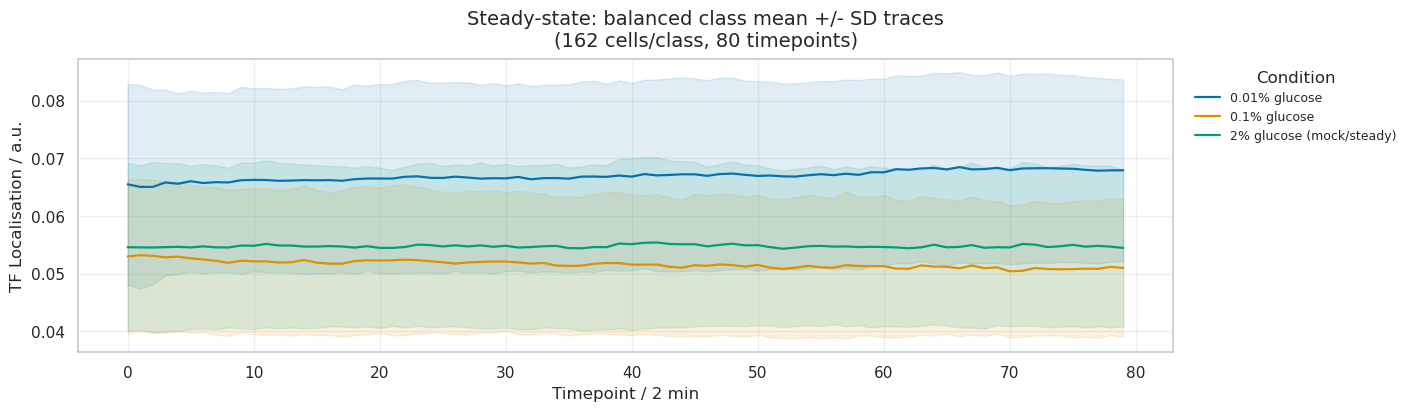

In [6]:
def plot_balanced_traces(d, dataset_tag, fig_path):
    'Mean +/- SD traces per class for the balanced (un-normalised) dataset.'
    X_bal       = d["X_bal"]
    y_bal       = d["y_bal"]
    class_names = d["class_names"]
    n_cls       = len(class_names)
    n_tp        = X_bal.shape[1]
    palette     = sns.color_palette("colorblind", n_colors=n_cls)

    fig, ax = plt.subplots(figsize=(14, 4), constrained_layout=True)
    for i, cls in enumerate(class_names):
        mask = y_bal == i
        mean = X_bal[mask].mean(axis=0)
        sd   = X_bal[mask].std(axis=0, ddof=1)
        ax.plot(np.arange(n_tp), mean, label=cls, color=palette[i], linewidth=1.6)
        ax.fill_between(np.arange(n_tp), mean - sd, mean + sd, color=palette[i], alpha=0.12)
    ax.set_xlabel("Timepoint / 2 min")
    ax.set_ylabel("TF Localisation / a.u.")
    ax.grid(alpha=0.3)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False,
              title="Condition", fontsize=9)
    fig.suptitle(f"{dataset_tag}: balanced class mean +/- SD traces\n"
                 f"({d['min_count']} cells/class, {n_tp} timepoints)", fontsize=14)
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    plt.show()


plot_balanced_traces(ss, "Steady-state",
                     IY033_DIR / "IY033_condition_ss_balanced_traces.png")

## 6. Raw SVM

In [7]:
def run_raw_svm(d, dataset_tag):
    'RBF-SVM on flat truncated (un-normalised) time series.'
    print(f"\n=== Raw SVM (RBF) -- {dataset_tag} (T={d['min_T']}) ===")
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
    ])
    pipe.fit(d["X_train_raw"], d["y_train"])
    y_pred = pipe.predict(d["X_test_raw"])
    acc    = accuracy_score(d["y_test"], y_pred)
    print(f"Accuracy: {acc:.4f}  (chance={1/len(d['class_names']):.4f})")
    print(classification_report(d["y_test"], y_pred, target_names=d["class_names"]))
    return acc, y_pred

ss_svm_acc, ss_svm_pred = run_raw_svm(ss, "Steady-state")


=== Raw SVM (RBF) -- Steady-state (T=80) ===
Accuracy: 0.6327  (chance=0.3333)
                          precision    recall  f1-score   support

           0.01% glucose       0.77      0.94      0.85        32
            0.1% glucose       0.59      0.67      0.63        33
2% glucose (mock/steady)       0.45      0.30      0.36        33

                accuracy                           0.63        98
               macro avg       0.61      0.64      0.61        98
            weighted avg       0.60      0.63      0.61        98



## 7. Catch22 + SVM

Features are length-agnostic — extracted from full-length series.

In [8]:
from features.catch22 import run_catch22_series_svm

ss_c22_acc, ss_c22_pred = run_catch22_series_svm(ss, "Steady-state", random_state=RANDOM_STATE)


=== Catch22 + SVM (RBF) -- Steady-state ===


Feature matrix: 22 features


Accuracy: 0.4898  (chance=0.3333)
                          precision    recall  f1-score   support

           0.01% glucose       0.48      0.47      0.48        32
            0.1% glucose       0.51      0.61      0.56        33
2% glucose (mock/steady)       0.46      0.39      0.43        33

                accuracy                           0.49        98
               macro avg       0.49      0.49      0.49        98
            weighted avg       0.49      0.49      0.49        98



## 8. SimCLR Model Registry

In [9]:
from utils.embeddings import load_simclr_model, encode_channel

NORM_OVERRIDES = {
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125632_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_132219_model": "joint",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model": "global",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model": "joint",
}


from utils.embeddings import parse_arch_from_name as parse_arch


from functools import partial
from utils.embeddings import (
    make_checkpoint_short_label,
    make_unique_checkpoint_label,
)

make_short_label = partial(
    make_checkpoint_short_label,
    norm_overrides=NORM_OVERRIDES,
)
make_unique_label = partial(
    make_unique_checkpoint_label,
    norm_overrides=NORM_OVERRIDES,
)





CKPT_DIRS      = ["EXP-26-IY017", "EXP-26-IY022", "EXP-26-IY023", "EXP-26-IY024"]
MODEL_REGISTRY = []
for idx, _d in enumerate(CKPT_DIRS):
    for p in sorted((EXP_DIR / _d).glob("*.pth")):
        MODEL_REGISTRY.append({
            "path": p,
            "short_label": make_short_label(p),
            "label": make_unique_label(p, len(MODEL_REGISTRY)),
            "experiment": _d,
        })

EXP_COLOR_MAP = {
    "EXP-26-IY017": sns.color_palette("colorblind")[0],
    "EXP-26-IY022": sns.color_palette("colorblind")[1],
    "EXP-26-IY023": sns.color_palette("colorblind")[2],
    "EXP-26-IY024": sns.color_palette("colorblind")[4],
}

print(f"Found {len(MODEL_REGISTRY)} checkpoints:")
for row in MODEL_REGISTRY:
    arch = parse_arch(row["path"].name)
    print(f"  [{row['experiment']}]  {row['label']:<52s}  d_model={arch['d_model']}")


def run_simclr_svm(model, X_tr, X_te, y_tr, y_te, device):
    'Encode -> StandardScale -> RBF-SVM; return (accuracy, y_pred).'
    Z_tr    = encode_channel(model, X_tr, device)
    Z_te    = encode_channel(model, X_te, device)
    scaler  = StandardScaler()
    Z_tr_sc = scaler.fit_transform(Z_tr)
    Z_te_sc = scaler.transform(Z_te)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
    clf.fit(Z_tr_sc, y_tr)
    y_pred = clf.predict(Z_te_sc)
    return accuracy_score(y_te, y_pred), y_pred

Found 34 checkpoints:
  [EXP-26-IY017]  IY017-inst b100 D128 #00                              d_model=128
  [EXP-26-IY017]  IY017-inst b100 D128 #01                              d_model=128
  [EXP-26-IY017]  IY017-inst b1024 D16 164413                           d_model=16
  [EXP-26-IY017]  IY017-inst b1024 D16 061239                           d_model=16
  [EXP-26-IY017]  IY017-inst b128 D16 151037                            d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16 #05                                d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16 #06                                d_model=16
  [EXP-26-IY017]  IY017-inst b2048 D16 162432                           d_model=16
  [EXP-26-IY017]  IY017-inst b256 D16 154425                            d_model=16
  [EXP-26-IY017]  IY017-inst b32 D128 #09                               d_model=128
  [EXP-26-IY017]  IY017-inst b4096 D16 140729                           d_model=16
  [EXP-26-IY017]  IY017-inst b4096 D16 023947                 

## 9. Run SimCLR Models

In [10]:
def run_all_models(d, dataset_name, csv_tag):
    'Evaluate all checkpoints; return results DataFrame and predictions dict.'
    rows, preds = [], {}
    n_cls  = len(d["class_names"])
    chance = 1.0 / n_cls
    print(f"  {n_cls} classes, chance={chance:.4f}")
    for row in MODEL_REGISTRY:
        ckpt_path = row["path"]
        print(f"  {row['label']:<55s}", end=" ")
        try:
            model = load_simclr_model(ckpt_path, DEVICE)
            acc, y_pred = run_simclr_svm(
                model,
                d["X_train"], d["X_test"],
                d["y_train"], d["y_test"],
                DEVICE
            )
            preds[str(ckpt_path)] = y_pred
            rows.append({
                "label":           row["label"],
                "short_label":     row["short_label"],
                "experiment":      row["experiment"],
                "checkpoint":      str(ckpt_path),
                "checkpoint_name": ckpt_path.name,
                "accuracy":        acc,
                "status":          "ok",
                "error":           "",
            })
            print(f"acc={acc:.4f}  (+{acc - chance:.4f})")
        except Exception as exc:
            rows.append({
                "label": row["label"], "short_label": row["short_label"],
                "experiment": row["experiment"],
                "checkpoint": str(ckpt_path), "checkpoint_name": ckpt_path.name,
                "accuracy": np.nan, "status": "failed", "error": str(exc),
            })
            print(f"FAILED: {exc}")

    results_df = (
        pd.DataFrame(rows)
        .sort_values("accuracy", ascending=False, na_position="last")
        .reset_index(drop=True)
    )
    csv_path = IY033_DIR / f"{csv_tag}_simclr_results.csv"
    results_df.to_csv(csv_path, index=False)
    print(f"\nSaved: {csv_path}")
    return results_df, preds


print("=" * 70)
print("STEADY-STATE dataset")
print("=" * 70)
ss_simclr_df, ss_simclr_preds = run_all_models(ss, "ss", "IY033_condition_ss")

STEADY-STATE dataset
  3 classes, chance=0.3333
  IY017-inst b100 D128 #00                                

acc=0.6020  (+0.2687)
  IY017-inst b100 D128 #01                                

acc=0.5510  (+0.2177)
  IY017-inst b1024 D16 164413                             

acc=0.5510  (+0.2177)
  IY017-inst b1024 D16 061239                             

acc=0.6633  (+0.3299)
  IY017-inst b128 D16 151037                              

...

acc=0.6429  (+0.3095)
  IY023-batch b64 D8 120151                               

acc=0.6224  (+0.2891)
  IY024-batch b64 D16 122627                              

acc=0.5816  (+0.2483)
  IY024-batch b64 D16 210002                              

acc=0.6531  (+0.3197)
  IY024-batch b64 D8 203126                               

acc=0.6224  (+0.2891)

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY033/IY033_condition_ss_simclr_results.csv


## 10. Results Comparison

- **SimCLR bar chart** with Raw SVM & Catch22+SVM as reference lines
- **Summary** grouped bar: Raw SVM vs Catch22+SVM vs best SimCLR
- **Confusion matrices**: 3 methods × 2 datasets (SS and Full)

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY033/IY033_condition_ss_simclr_results.png


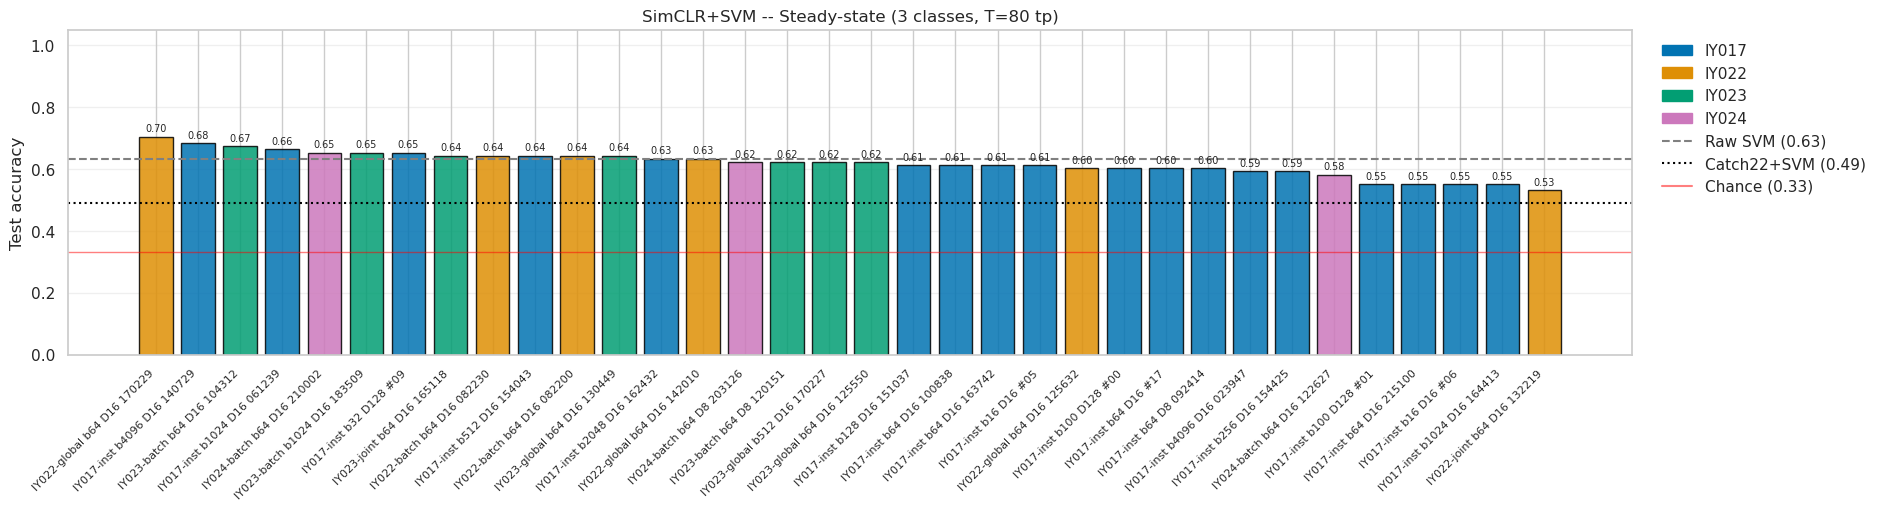

Saved: IY033_condition_summary_comparison.png


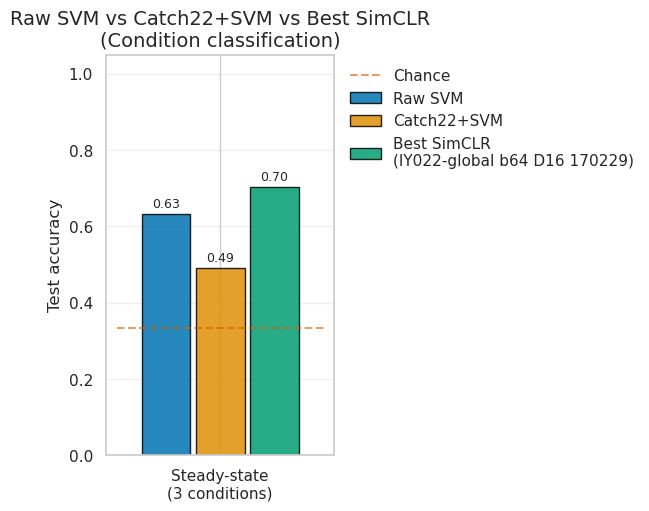


Best SimCLR -- SS: IY022-global b64 D16 170229  acc=0.7041
Saved: IY033_condition_confusion_matrices.png


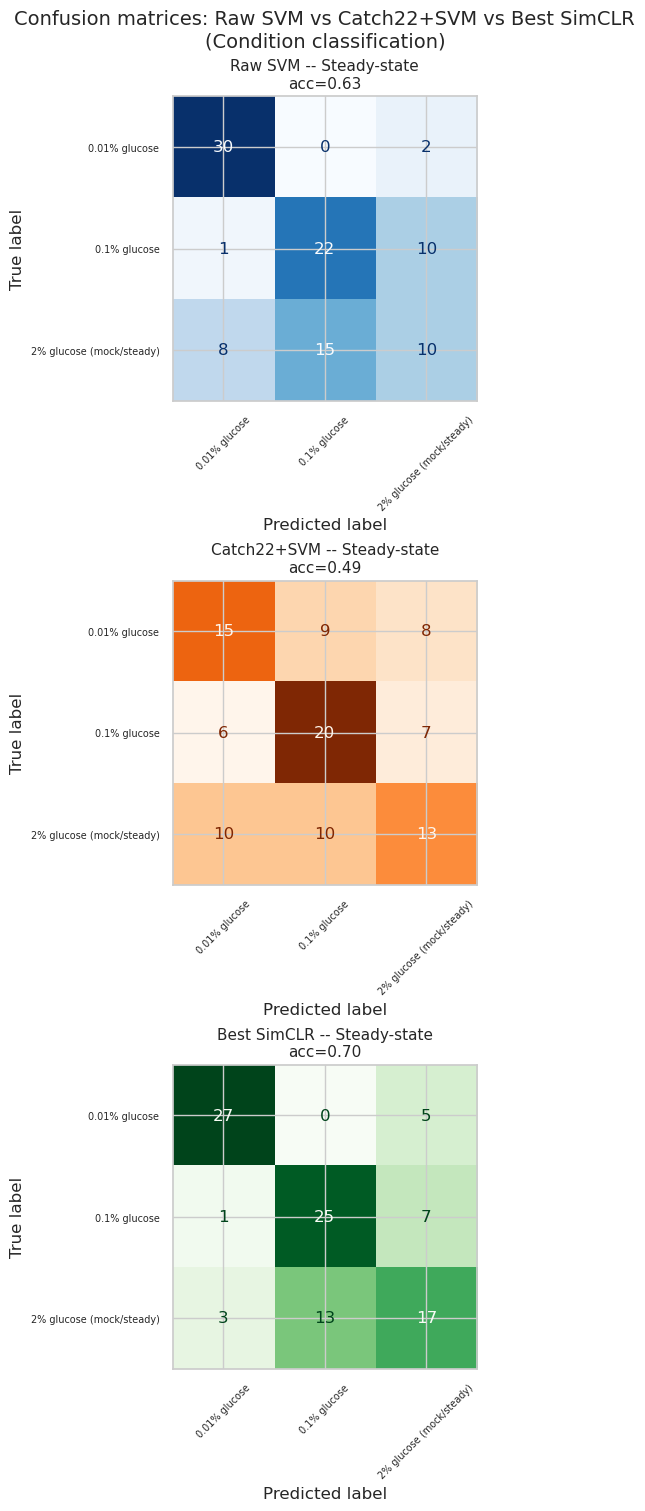

In [11]:
ss_simclr_valid = ss_simclr_df[ss_simclr_df["status"] == "ok"]


def plot_simclr_bar(valid, d, dataset_tag, svm_acc, c22_acc, fig_path):
    'All-checkpoint bar chart with baselines drawn as reference lines.'
    n_cls  = len(d["class_names"])
    chance = 1.0 / n_cls
    bar_colors = [EXP_COLOR_MAP.get(exp, (0.5,) * 3) for exp in valid["experiment"]]
    fig, ax = plt.subplots(figsize=(max(14, len(valid) * 0.55), 5), constrained_layout=True)
    bars = ax.bar(range(len(valid)), valid["accuracy"],
                  color=bar_colors, alpha=0.85, edgecolor="black")
    ax.axhline(svm_acc, color="grey",  linestyle="--", lw=1.5,
               label=f"Raw SVM ({svm_acc:.2f})")
    ax.axhline(c22_acc, color="black", linestyle=":",  lw=1.5,
               label=f"Catch22+SVM ({c22_acc:.2f})")
    ax.axhline(chance,  color="red",   linestyle="-",  lw=1.0, alpha=0.5,
               label=f"Chance ({chance:.2f})")
    ax.set_xticks(range(len(valid)))
    ax.set_xticklabels(valid["label"], rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Test accuracy")
    ax.set_title(f"SimCLR+SVM -- {dataset_tag} ({n_cls} classes, T={d['min_T']} tp)")
    ax.grid(axis="y", alpha=0.3)
    for bar, acc in zip(bars, valid["accuracy"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{acc:.2f}", ha="center", va="bottom", fontsize=7)
    palette = sns.color_palette("colorblind")
    legend_handles = [
        Patch(color=EXP_COLOR_MAP.get(_d, palette[7]), label=_d.replace("EXP-26-", ""))
        for _d in CKPT_DIRS
    ] + [
        plt.Line2D([0], [0], color="grey",  ls="--", label=f"Raw SVM ({svm_acc:.2f})"),
        plt.Line2D([0], [0], color="black", ls=":",  label=f"Catch22+SVM ({c22_acc:.2f})"),
        plt.Line2D([0], [0], color="red",   ls="-",  alpha=0.5, label=f"Chance ({chance:.2f})"),
    ]
    ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    plt.show()


plot_simclr_bar(ss_simclr_valid, ss, "Steady-state",
                ss_svm_acc, ss_c22_acc,
                IY033_DIR / "IY033_condition_ss_simclr_results.png")


# ── Summary: Raw SVM vs Catch22+SVM vs best SimCLR ──────────────────────────
ss_best  = ss_simclr_valid.iloc[0]
ss_chance = 1.0 / len(ss["class_names"])

palette = sns.color_palette("colorblind")
methods = ["Raw SVM", "Catch22+SVM", f"Best SimCLR\n({ss_best['label']})"]
x = np.array([0])
width = 0.22

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
for i, ss_val in enumerate([ss_svm_acc, ss_c22_acc, ss_best["accuracy"]]):
    bar = ax.bar(x + (i - 1) * width, [ss_val], width=width * 0.9,
                 label=methods[i], color=palette[i], alpha=0.85, edgecolor="black")
    ax.text(bar[0].get_x() + bar[0].get_width() / 2, bar[0].get_height() + 0.01,
            f"{ss_val:.2f}", ha="center", va="bottom", fontsize=9)

ax.plot(x[0] + np.array([-0.42, 0.42]), [ss_chance, ss_chance], "r--", lw=1.5, alpha=0.6, label="Chance")
ax.set_xticks(x)
ax.set_xticklabels([f"Steady-state\n({len(ss['class_names'])} conditions)"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test accuracy")
ax.set_title("Raw SVM vs Catch22+SVM vs Best SimCLR\n(Condition classification)", fontsize=14)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
ax.grid(axis="y", alpha=0.3)
fig.savefig(IY033_DIR / "IY033_condition_summary_comparison.png", dpi=150, bbox_inches="tight")
print("Saved: IY033_condition_summary_comparison.png")
plt.show()

print(f"\nBest SimCLR -- SS: {ss_best['label']}  acc={ss_best['accuracy']:.4f}")


# ── Confusion matrices: 3 methods ──────────────────────────────────────────
n_cls_ss = len(ss["class_names"])
cm_h     = max(5, n_cls_ss * 0.5 + 2)

fig, axes = plt.subplots(3, 1, figsize=(7, cm_h * 3), constrained_layout=True)
cm_entries = [
    (axes[0], ss, "Raw SVM",     ss_svm_pred,                            "Steady-state"),
    (axes[1], ss, "Catch22+SVM", ss_c22_pred,                            "Steady-state"),
    (axes[2], ss, "Best SimCLR", ss_simclr_preds[ss_best["checkpoint"]], "Steady-state"),
]
cm_palette = {"Raw SVM": "Blues", "Catch22+SVM": "Oranges", "Best SimCLR": "Greens"}
for ax, d, method, y_pred, dataset_tag in cm_entries:
    acc = accuracy_score(d["y_test"], y_pred)
    ConfusionMatrixDisplay.from_predictions(
        d["y_test"], y_pred,
        display_labels=d["class_names"],
        ax=ax, colorbar=False, cmap=cm_palette[method], xticks_rotation=45,
    )
    ax.set_title(f"{method} -- {dataset_tag}\nacc={acc:.2f}", fontsize=11)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Confusion matrices: Raw SVM vs Catch22+SVM vs Best SimCLR\n"
             "(Condition classification)", fontsize=14)
fig.savefig(IY033_DIR / "IY033_condition_confusion_matrices.png", dpi=150, bbox_inches="tight")
print("Saved: IY033_condition_confusion_matrices.png")
plt.show()